In [14]:
# =========================
# Cell 1: Imports + config
# =========================
import os
import re
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Point this to your eval_results directory
directory_path = "runs/qwen35_9b_both_aug/eval_results/"

json_files = [
    f for f in glob.glob(os.path.join(directory_path, "*.json"))
    if os.path.basename(f) != "all_metrics.json"
]

print(f"Found {len(json_files)} result files")
for f in sorted(json_files)[:5]:
    print(" -", os.path.basename(f))

Found 4 result files
 - base_pretrained.json
 - checkpoint-1308.json
 - checkpoint-436.json
 - checkpoint-872.json


In [15]:
# ==========================================
# Cell 2: Helpers to read the new file shape
# ==========================================
ALL_FIELDS = ["hazard_label", "hazard_present", "zone_relation", "object_state", "object_direction"]
FIELDS_BY_SUBSET = {
    "combined": ["hazard_label", "hazard_present", "zone_relation", "object_state", "object_direction"],
    "forklift": ["hazard_label", "hazard_present", "zone_relation", "object_state", "object_direction"],
    "robot": ["hazard_label", "hazard_present", "zone_relation", "object_state"],
}

def parse_step(filename: str) -> int:
    name = filename.lower()
    if "base" in name:
        return 0
    if "final" in name:
        return 999999

    m = re.search(r"checkpoint[-_]?(\d+)", name)
    if m:
        return int(m.group(1))

    m = re.search(r"[-_](\d+)\.json$", name)
    if m:
        return int(m.group(1))

    return -1

def safe_get(d, *keys, default=None):
    cur = d
    for k in keys:
        if not isinstance(cur, dict):
            return default
        cur = cur.get(k)
        if cur is None:
            return default
    return cur

def get_field_f1(subset_metrics, field):
    return safe_get(subset_metrics, "per_field_metrics", field, "macro_f1", default=np.nan)

def get_field_fp(subset_metrics, field):
    labels = safe_get(subset_metrics, "per_field_metrics", field, "labels", default={}) or {}
    return sum((info or {}).get("fp", 0) for info in labels.values())

def build_summary_row(file_path, content):
    filename = os.path.basename(file_path)
    metrics = content.get("metrics", {})
    row = {
        "checkpoint": filename.replace(".json", ""),
        "filename": filename,
        "step": parse_step(filename),
        "adapter_name": metrics.get("adapter_name"),
        "inference_time_sec": metrics.get("inference_time_sec", np.nan),
        "samples_per_sec": metrics.get("samples_per_sec", np.nan),
    }

    for subset in ["combined", "forklift", "robot"]:
        subset_metrics = safe_get(metrics, subset, default=None)
        if subset_metrics is None:
            subset_metrics = safe_get(metrics, "by_task", subset, default={}) or {}

        row[f"{subset}_total_samples"] = subset_metrics.get("total_samples", np.nan)
        row[f"{subset}_exact_match_accuracy"] = subset_metrics.get("exact_match_accuracy", np.nan)
        row[f"{subset}_relevant_field_accuracy"] = subset_metrics.get("relevant_field_accuracy", np.nan)
        row[f"{subset}_parse_failures"] = subset_metrics.get("parse_failures", np.nan)
        row[f"{subset}_gt_parse_failures"] = subset_metrics.get("ground_truth_parse_failures", np.nan)
        row[f"{subset}_hazard_f1"] = safe_get(subset_metrics, "hazard_present_binary", "f1", default=np.nan)
        row[f"{subset}_hazard_recall"] = safe_get(subset_metrics, "hazard_present_binary", "recall", default=np.nan)
        row[f"{subset}_hazard_precision"] = safe_get(subset_metrics, "hazard_present_binary", "precision", default=np.nan)

        for field in ALL_FIELDS:
            row[f"{subset}_{field}_acc"] = safe_get(subset_metrics, "per_field_accuracy", field, default=np.nan)
            row[f"{subset}_{field}_f1"] = get_field_f1(subset_metrics, field)
            row[f"{subset}_{field}_fp"] = get_field_fp(subset_metrics, field)

    return row

summary_rows = []

for file_path in json_files:
    with open(file_path, "r", encoding="utf-8") as f:
        content = json.load(f)
    summary_rows.append(build_summary_row(file_path, content))

summary_df = pd.DataFrame(summary_rows).sort_values(["step", "checkpoint"]).reset_index(drop=True)
summary_df.head()

,checkpoint,filename,step,adapter_name,inference_time_sec,samples_per_sec,combined_total_samples,combined_exact_match_accuracy,combined_relevant_field_accuracy,combined_parse_failures,...,robot_hazard_present_fp,robot_zone_relation_acc,robot_zone_relation_f1,robot_zone_relation_fp,robot_object_state_acc,robot_object_state_f1,robot_object_state_fp,robot_object_direction_acc,robot_object_direction_f1,robot_object_direction_fp
0,base_pretrained,base_pretrained.json,0,base_pretrained,3443.52,0.1673,576,0.0833,0.2213,0,...,419,0.0295,0.0287,427,0.1909,0.1647,356,NaN,NaN,0
1,checkpoint-436,checkpoint-436.json,436,checkpoint-436,2995.88,0.1923,576,0.8854,0.9266,0,...,21,0.9705,0.4925,13,0.9750,0.4937,11,NaN,NaN,0
2,checkpoint-872,checkpoint-872.json,872,checkpoint-872,2937.48,0.1961,576,0.9531,0.9607,0,...,15,0.9705,0.4925,13,0.9886,0.8500,5,NaN,NaN,0
3,checkpoint-1308,checkpoint-1308.json,1308,checkpoint-1308,2845.65,0.2024,576,0.9253,0.9459,0,...,15,0.9705,0.4925,13,0.9886,0.8500,5,NaN,NaN,0


In [16]:
# ==================================
# Cell 3: Quick summary table to use
# ==================================
core_cols = [
    "checkpoint", "step",
    "combined_exact_match_accuracy", "combined_relevant_field_accuracy", "combined_hazard_f1",
    "forklift_exact_match_accuracy", "forklift_relevant_field_accuracy", "forklift_hazard_f1",
    "robot_exact_match_accuracy", "robot_relevant_field_accuracy", "robot_hazard_f1",
    "samples_per_sec"
]

display(summary_df[core_cols].round(4))

,checkpoint,step,combined_exact_match_accuracy,combined_relevant_field_accuracy,combined_hazard_f1,forklift_exact_match_accuracy,forklift_relevant_field_accuracy,forklift_hazard_f1,robot_exact_match_accuracy,robot_relevant_field_accuracy,robot_hazard_f1,samples_per_sec
0,base_pretrained,0,0.0833,0.2213,0.0000,0.3309,0.5897,0.0000,0.0068,0.0790,0.0000,0.1673
1,checkpoint-436,436,0.8854,0.9266,0.9555,0.6691,0.8338,0.0000,0.9523,0.9625,0.9756,0.1923
2,checkpoint-872,872,0.9531,0.9607,0.9692,0.9118,0.9294,0.5000,0.9659,0.9727,0.9824,0.1961
3,checkpoint-1308,1308,0.9253,0.9459,0.9820,0.7941,0.8765,0.9714,0.9659,0.9727,0.9824,0.2024


In [17]:
from adjustText import adjust_text

# =======================================================
# Plot helpers with automatic label de-overlap
# =======================================================
def annotate_series(x_vals, y_vals, texts, fmt="{:.2f}", fontsize=8):
    for x, y in zip(x_vals, y_vals):
        if pd.isna(y):
            continue
        txt = plt.text(
            x, y, fmt.format(y),
            fontsize=fontsize,
            ha="center",
            va="bottom",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=0.2)
        )
        texts.append(txt)


def plot_metric_family(df, subset, metric_suffix, title=None, figsize=(14, 5)):
    valid_fields = []
    for field in FIELDS_BY_SUBSET[subset]:
        col = f"{subset}_{field}_{metric_suffix}"
        if col in df.columns and df[col].notna().any():
            valid_fields.append((field, col))

    if not valid_fields:
        print(f"No data to plot for {subset} / {metric_suffix}")
        return

    plt.figure(figsize=figsize)
    texts = []

    for field, col in valid_fields:
        label = field.replace("_", " ").title()
        plt.plot(df["checkpoint"], df[col], marker="o", linewidth=1.8, label=label)

        fmt = "{:.0f}" if metric_suffix == "fp" else "{:.2f}"
        annotate_series(df["checkpoint"], df[col], texts, fmt=fmt)

    adjust_text(
        texts,
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.5),
        only_move={"points": "y", "text": "y"},
        force_text=0.8,
        force_points=0.3
    )

    if title is None:
        title = f"{subset.title()} - {metric_suffix.upper()}"

    plt.title(title, fontsize=13, fontweight="bold")
    plt.xlabel("Checkpoint")
    plt.ylabel(metric_suffix.upper())
    plt.xticks(rotation=45, ha="right")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


def plot_overall_metrics(df, subset, figsize=(14, 5)):
    cols = [
        f"{subset}_exact_match_accuracy",
        f"{subset}_relevant_field_accuracy",
        f"{subset}_hazard_f1",
    ]
    labels = ["Exact Match", "Relevant Field Acc", "Hazard F1"]

    plt.figure(figsize=figsize)
    texts = []

    for col, label in zip(cols, labels):
        if col in df.columns and df[col].notna().any():
            plt.plot(df["checkpoint"], df[col], marker="o", linewidth=2, label=label)
            annotate_series(df["checkpoint"], df[col], texts, fmt="{:.2f}")

    adjust_text(
        texts,
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.5),
        only_move={"points": "y", "text": "y"},
        force_text=0.8,
        force_points=0.3
    )

    plt.title(f"{subset.title()} - Overall Scores", fontsize=13, fontweight="bold")
    plt.xlabel("Checkpoint")
    plt.ylabel("Score")
    plt.xticks(rotation=45, ha="right")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

0 [-0.12480382  0.84697627]
4 [-0.39062195 -0.21379744]
1 [-0.39017365  0.17790699]
5 [ 0.83976263 -0.85804099]
2 [-0.03722267 -0.74019306]
6 [-0.81112352 -0.56726096]
3 [ 0.50903509 -0.81788462]
7 [0.09415705 0.49687971]


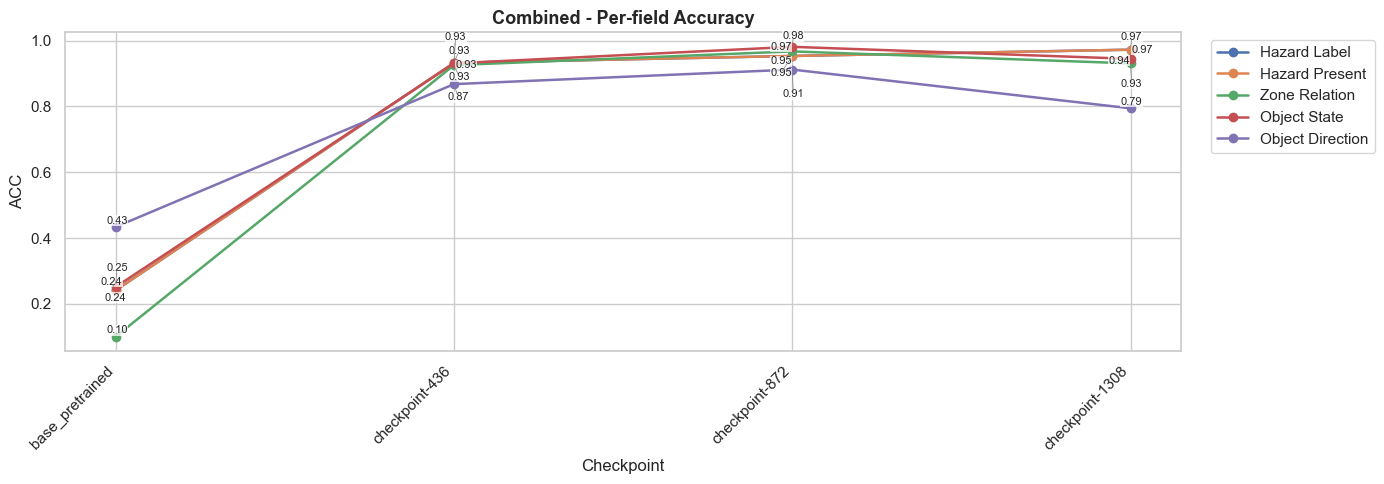

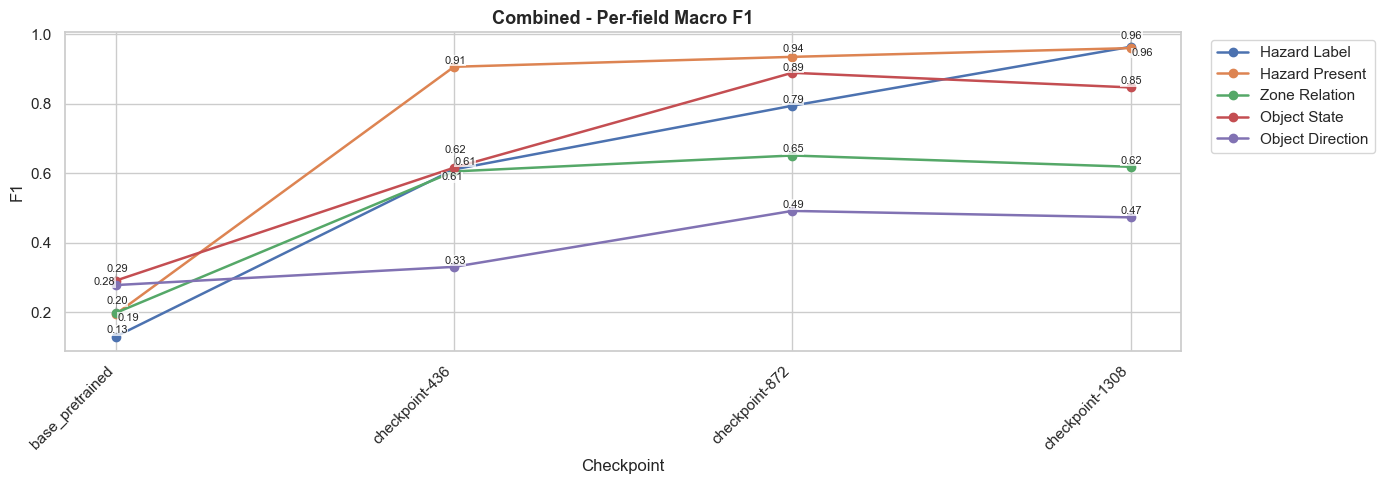

0 [-0.52211671  0.59969727]
4 [-0.35096215  0.5348781 ]
1 [-0.54820303 -0.86804536]
5 [-0.99372918  0.69574054]
2 [ 0.97619866 -0.06090561]
6 [0.96393382 0.08149669]
3 [-0.67936217  0.98441768]
7 [-0.20883011 -0.41467755]


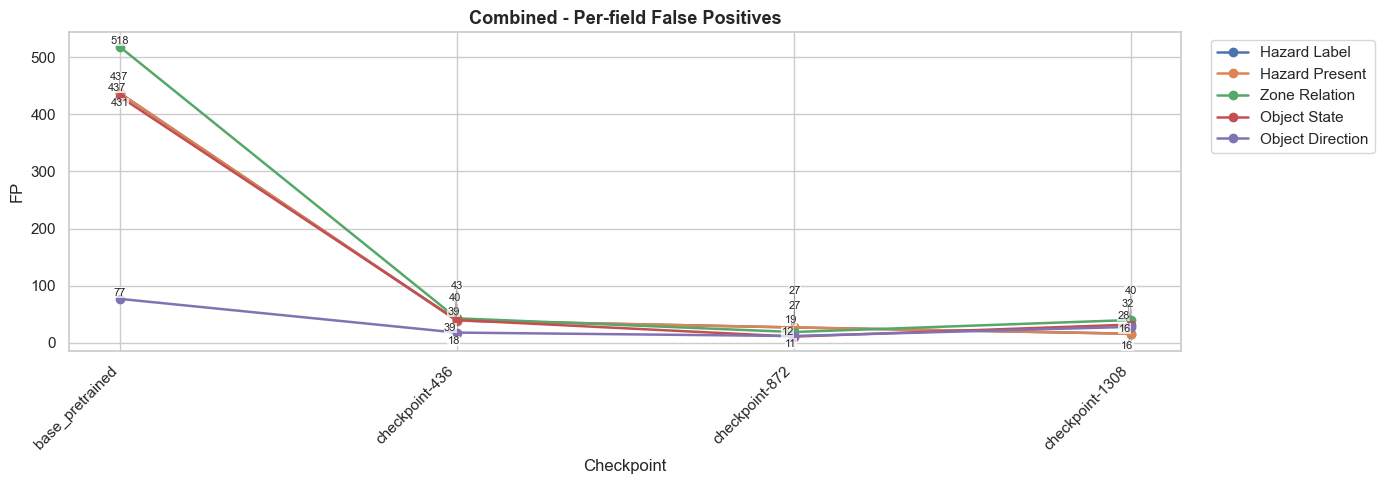

0 [0.43958632 0.75303157]
4 [ 0.63792558 -0.67023611]
1 [ 0.40393777 -0.1485018 ]
5 [ 0.17079448 -0.39481838]
17 [-0.19704381 -0.62283651]
2 [-0.40086068 -0.0219705 ]
6 [ 0.65059429 -0.09635354]
18 [-0.79453218  0.34761328]
10 [ 0.58830776 -0.71244943]
14 [-0.77949765  0.53295705]
11 [-0.25646162  0.23698794]
15 [-0.28280977  0.5370132 ]
3 [ 0.93183525 -0.77791926]
7 [-0.98773758 -0.37984364]


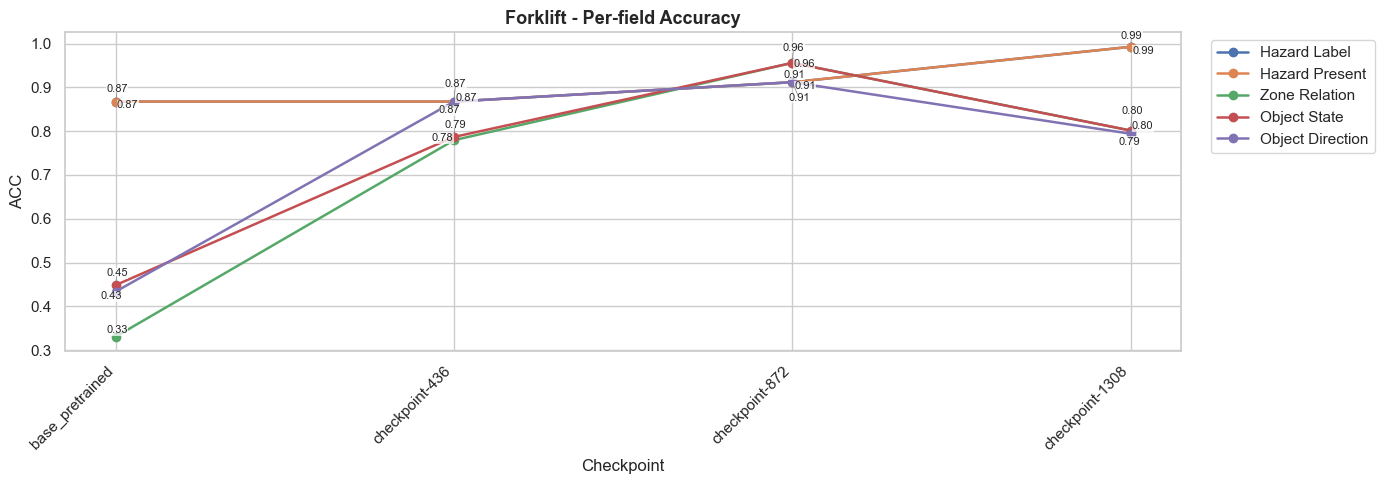

0 [-0.45515752  0.59664947]
4 [ 0.79174322 -0.69851121]
1 [-0.16679199 -0.6112358 ]
5 [-0.8935032  -0.14942556]
2 [-0.4706942  -0.31030625]
6 [-0.47271094 -0.19980002]
10 [-0.36808021 -0.13835542]
14 [-0.82601384 -0.8962252 ]
3 [ 0.85530796 -0.85119394]
7 [-0.97005294 -0.24330967]


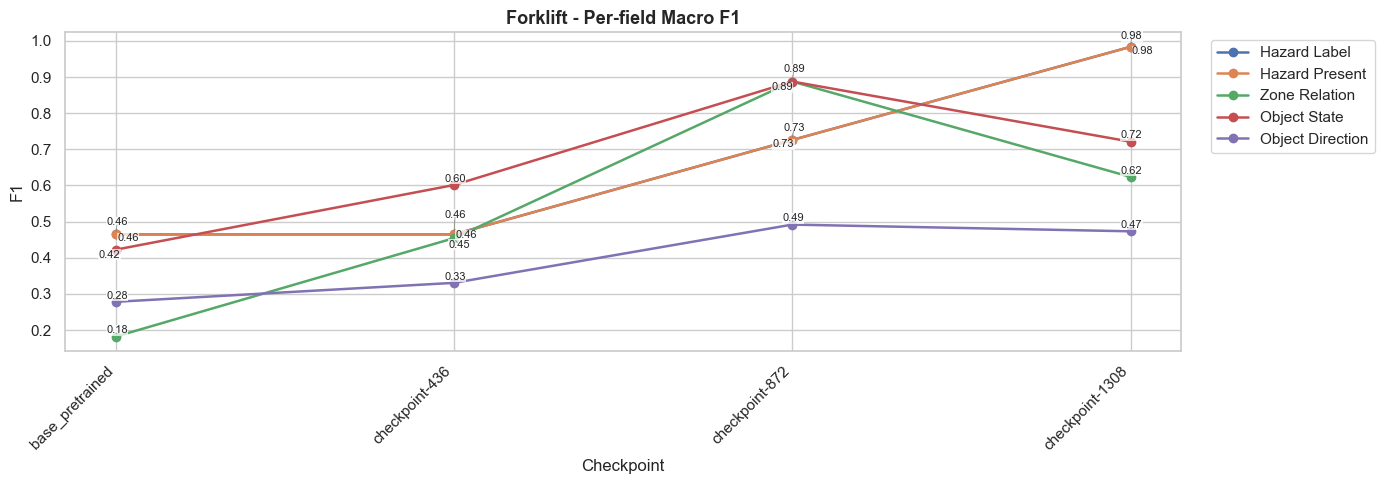

0 [-0.69046624 -0.93133426]
4 [-0.95306538  0.88225756]
1 [-0.39300667  0.82346444]
5 [-0.50918465  0.17541607]
17 [0.48674506 0.56547945]
10 [-0.7062877   0.78336705]
14 [0.2564129  0.94309163]
2 [ 0.33399681 -0.00097049]
6 [ 0.55527869 -0.86538773]
18 [ 0.05857647 -0.83826164]
3 [ 0.77412543 -0.7213235 ]
7 [-0.14829978  0.24861942]
11 [ 0.7520999  -0.21990205]
15 [ 0.64396484 -0.99069503]


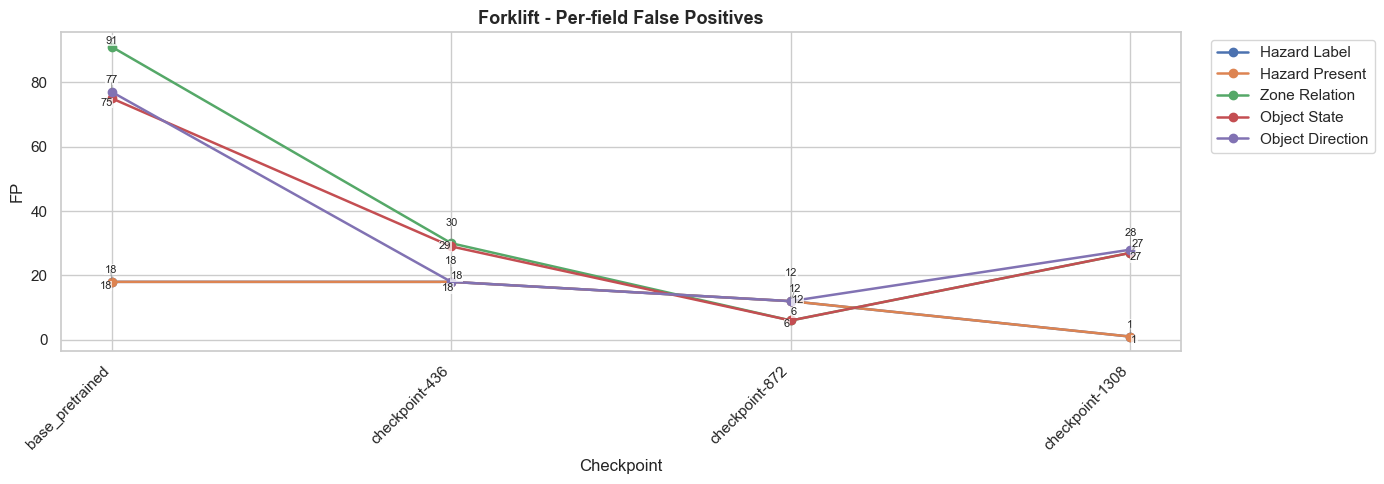

0 [0.54413255 0.73136054]
4 [-0.14265421 -0.66778638]
1 [-0.59709764 -0.59039085]
5 [0.09484919 0.24293168]
2 [-0.24863347 -0.05345533]
6 [-0.86387868 -0.84903637]
3 [-0.00891314  0.20426995]
7 [-0.8602113  -0.07006569]


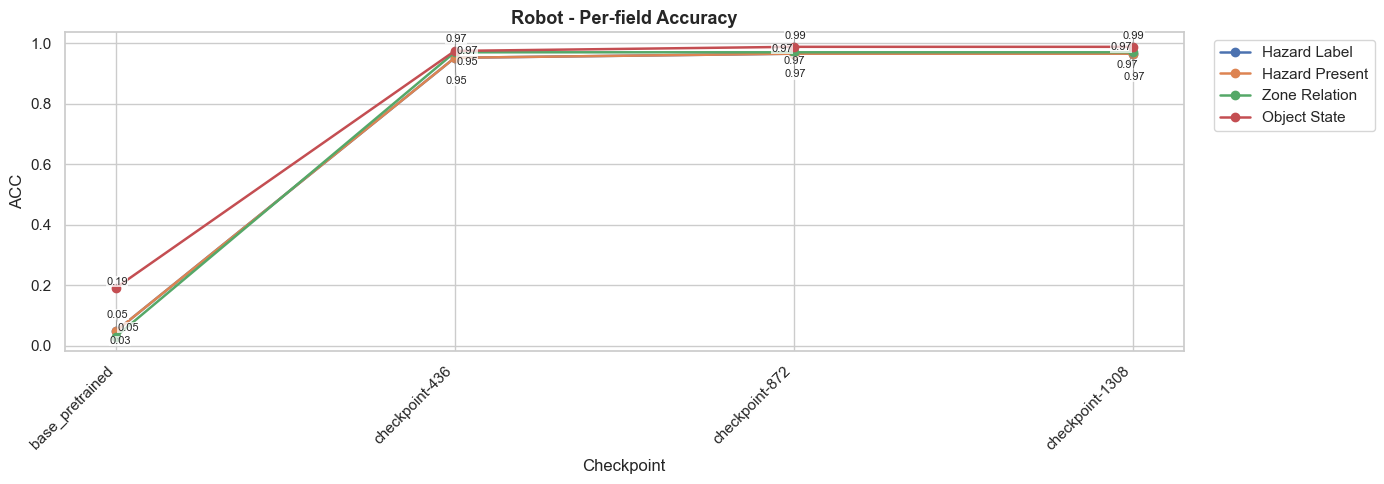

0 [ 0.17125208 -0.51494421]
4 [ 0.65593329 -0.07448597]
1 [-0.0106385   0.58665739]
5 [-0.12349941  0.05204263]
2 [0.396829   0.96387838]
6 [ 0.08507906 -0.61694011]
3 [0.8529624  0.12951201]
7 [ 0.48423673 -0.77896963]


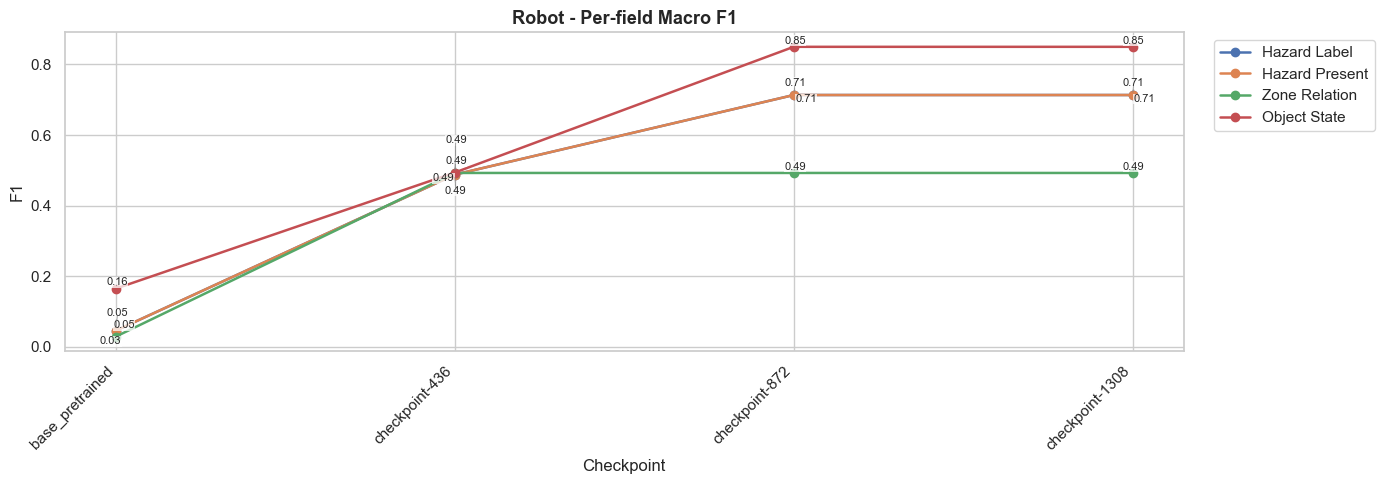

0 [-0.53424397 -0.48747238]
4 [ 0.33926148 -0.49925067]
1 [-0.22769114 -0.62937023]
5 [ 0.82958807 -0.541641  ]
2 [-0.82343228  0.14096985]
6 [-0.93122964  0.81164382]
3 [0.33744294 0.78855126]
7 [-0.32709919 -0.87795548]


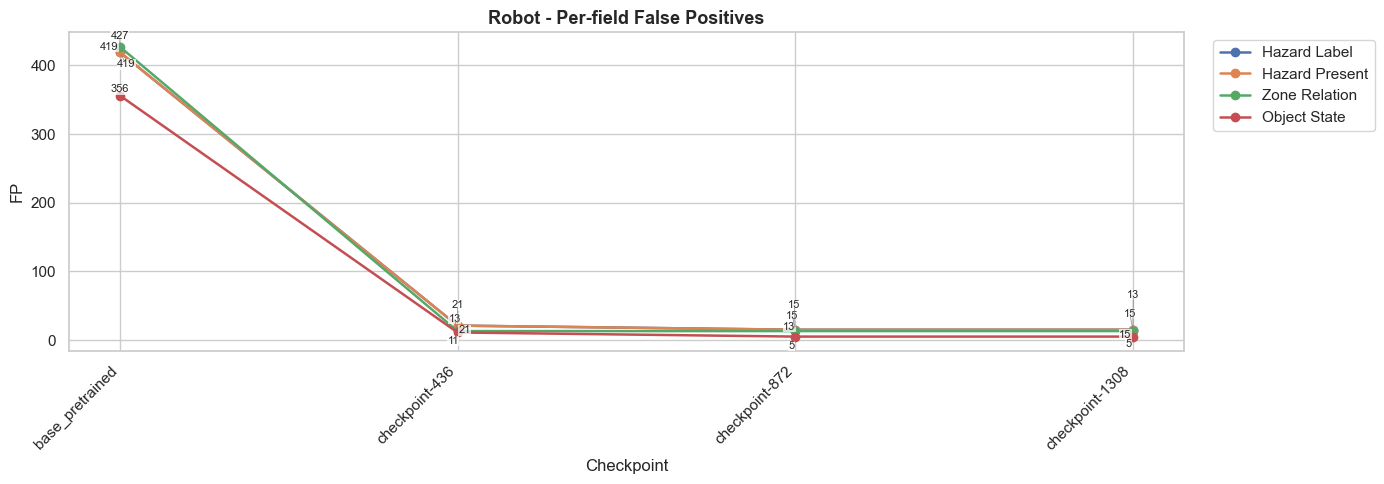

In [18]:
# ============================================
# Cell 6: Per-field ACC / F1 / FP for each set
# ============================================
plot_metric_family(summary_df, "combined", "acc", "Combined - Per-field Accuracy")
plot_metric_family(summary_df, "combined", "f1",  "Combined - Per-field Macro F1")
plot_metric_family(summary_df, "combined", "fp",  "Combined - Per-field False Positives")

plot_metric_family(summary_df, "forklift", "acc", "Forklift - Per-field Accuracy")
plot_metric_family(summary_df, "forklift", "f1",  "Forklift - Per-field Macro F1")
plot_metric_family(summary_df, "forklift", "fp",  "Forklift - Per-field False Positives")

plot_metric_family(summary_df, "robot", "acc", "Robot - Per-field Accuracy")
plot_metric_family(summary_df, "robot", "f1",  "Robot - Per-field Macro F1")
plot_metric_family(summary_df, "robot", "fp",  "Robot - Per-field False Positives")

In [19]:
# ===================================================
# Cell 7: Load per-sample rows from all result files
# ===================================================
sample_rows = []

for file_path in json_files:
    filename = os.path.basename(file_path)
    checkpoint = filename.replace(".json", "")
    step = parse_step(filename)

    with open(file_path, "r", encoding="utf-8") as f:
        content = json.load(f)

    per_sample = content.get("per_sample", [])
    for s in per_sample:
        gt = s.get("ground_truth") or {}
        pred = s.get("prediction_parsed") or {}
        meta = s.get("meta") or {}
        field_matches = s.get("field_matches") or {}

        row = {
            "checkpoint": checkpoint,
            "step": step,
            "sample_id": s.get("sample_id"),
            "task": s.get("task"),
            "exact_match": s.get("exact_match"),
            "ground_truth_parse_failed": s.get("ground_truth_parse_failed"),
            "inference_time_sec": s.get("inference_time_sec"),
            "hard_negative_bucket": s.get("hard_negative_bucket"),
            "prediction_raw": s.get("prediction_raw"),
            "ground_truth_text": s.get("ground_truth_text"),
            "source_video_id": meta.get("source_video_id"),
            "clip_start_sec": meta.get("clip_start_sec"),
            "clip_end_sec": meta.get("clip_end_sec"),
            "anchor_start_sec": meta.get("anchor_start_sec"),
            "anchor_end_sec": meta.get("anchor_end_sec"),
            "is_transition": meta.get("is_transition"),
            "is_ambiguous": meta.get("is_ambiguous"),
        }

        for field in ALL_FIELDS:
            row[f"gt_{field}"] = gt.get(field)
            row[f"pred_{field}"] = pred.get(field)
            row[f"match_{field}"] = field_matches.get(field)

        # True hazard false positive: GT says no, prediction says yes
        row["hazard_fp"] = (gt.get("hazard_present") == "no") and (pred.get("hazard_present") == "yes")

        # True hazard false negative: GT says yes, prediction says no
        row["hazard_fn"] = (gt.get("hazard_present") == "yes") and (pred.get("hazard_present") == "no")

        # Useful backup view: negative samples with any mistake
        row["negative_case_error"] = (gt.get("hazard_present") == "no") and (s.get("exact_match") is False)

        sample_rows.append(row)

samples_df = pd.DataFrame(sample_rows).sort_values(["step", "task", "sample_id"]).reset_index(drop=True)
samples_df.head()

,checkpoint,step,sample_id,task,exact_match,ground_truth_parse_failed,inference_time_sec,hard_negative_bucket,prediction_raw,ground_truth_text,...,match_zone_relation,gt_object_state,pred_object_state,match_object_state,gt_object_direction,pred_object_direction,match_object_direction,hazard_fp,hazard_fn,negative_case_error
0,base_pretrained,0,fork_금진Camera05_S20251213073941_E2025121307474...,forklift,False,False,7.6493,None,"```json\n{\n ""hazard_label"": ""no_hazard"",\n ...","{""hazard_label"": ""unsafe_forklift_approach"", ""...",...,False,moving,moving,True,towards,towards,True,False,True,False
1,base_pretrained,0,fork_금진Camera05_S20251213073941_E2025121307474...,forklift,False,False,6.3792,None,"```json\n{\n ""hazard_label"": ""no_hazard"",\n ...","{""hazard_label"": ""unsafe_forklift_approach"", ""...",...,False,moving,moving,True,towards,towards,True,False,True,False
2,base_pretrained,0,fork_금진Camera05_S20251213073941_E2025121307474...,forklift,False,False,6.6716,None,"```json\n{\n ""hazard_label"": ""no_hazard"",\n ...","{""hazard_label"": ""unsafe_forklift_approach"", ""...",...,False,moving,moving,True,towards,away,False,False,True,False
3,base_pretrained,0,fork_금진Camera05_S20251213073941_E2025121307474...,forklift,False,False,6.4643,None,"```json\n{\n ""hazard_label"": ""no_hazard"",\n ...","{""hazard_label"": ""unsafe_forklift_approach"", ""...",...,False,moving,moving,True,towards,towards,True,False,True,False
4,base_pretrained,0,fork_금진Camera05_S20251213073941_E2025121307474...,forklift,False,False,6.2654,None,"```json\n{\n ""hazard_label"": ""no_hazard"",\n ...","{""hazard_label"": ""unsafe_forklift_approach"", ""...",...,False,moving,moving,True,towards,towards,True,False,True,False


In [20]:
# ===========================================
# Cell 8: Count hazard FPs and FNs by run/task
# ===========================================
fp_fn_summary = (
    samples_df
    .groupby(["checkpoint", "task"], as_index=False)
    .agg(
        hazard_fp_count=("hazard_fp", "sum"),
        hazard_fn_count=("hazard_fn", "sum"),
        negative_case_error_count=("negative_case_error", "sum"),
        total_samples=("sample_id", "count"),
    )
    .sort_values(["checkpoint", "task"])
)

display(fp_fn_summary)

,checkpoint,task,hazard_fp_count,hazard_fn_count,negative_case_error_count,total_samples
0,base_pretrained,forklift,0,18,73,136
1,base_pretrained,robot,0,419,18,440
2,checkpoint-1308,forklift,0,1,27,136
3,checkpoint-1308,robot,15,0,15,440
4,checkpoint-436,forklift,0,18,27,136
5,checkpoint-436,robot,21,0,21,440
6,checkpoint-872,forklift,0,12,0,136
7,checkpoint-872,robot,15,0,15,440


0 [-0.76455867  0.02098503]
4 [-0.97601542 -0.3228054 ]


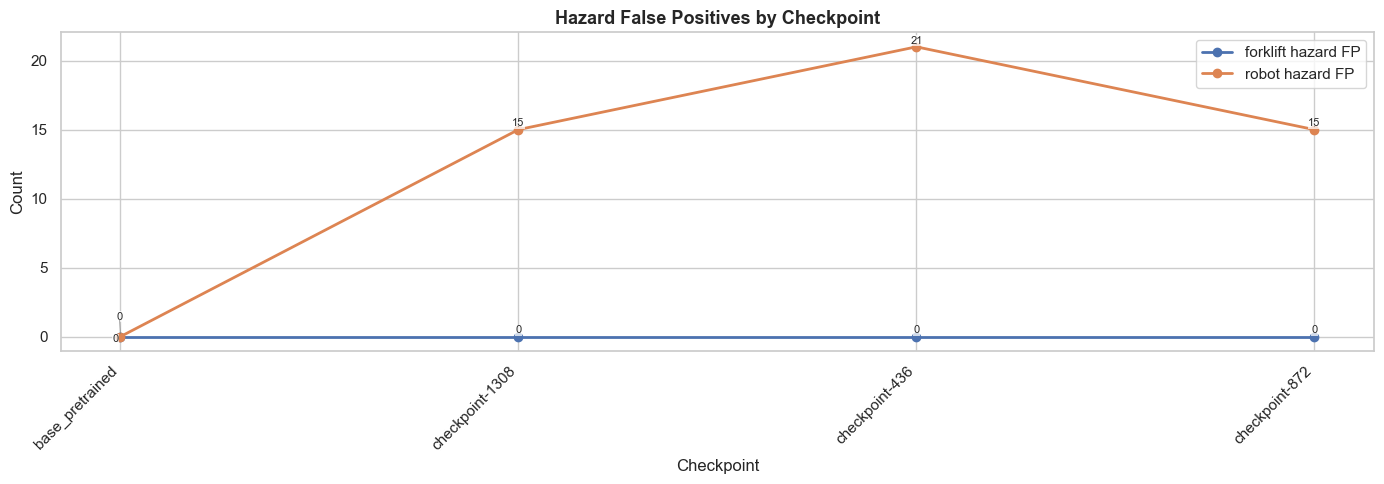

In [21]:
plt.figure(figsize=(14, 5))
texts = []

for task_name, sub_df in fp_fn_summary.groupby("task"):
    plt.plot(
        sub_df["checkpoint"],
        sub_df["hazard_fp_count"],
        marker="o",
        linewidth=2,
        label=f"{task_name} hazard FP"
    )
    annotate_series(sub_df["checkpoint"], sub_df["hazard_fp_count"], texts, fmt="{:.0f}")

adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.5),
    only_move={"points": "y", "text": "y"},
    force_text=0.8,
    force_points=0.3
)

plt.title("Hazard False Positives by Checkpoint", fontsize=13, fontweight="bold")
plt.xlabel("Checkpoint")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# Cell 8A: Ground-truth sample counts per label / per field
# ============================================================
count_rows = []

for _, row in samples_df.iterrows():
    task = row["task"]
    checkpoint = row["checkpoint"]

    for field in ALL_FIELDS:
        gt_col = f"gt_{field}"
        value = row.get(gt_col, None)

        # Skip robot object_direction since it is not a task field there
        if pd.isna(value) or value is None:
            continue

        count_rows.append({
            "checkpoint": checkpoint,
            "task": task,
            "field": field,
            "label": value,
            "count_type": "ground_truth"
        })

label_counts_df = (
    pd.DataFrame(count_rows)
    .groupby(["checkpoint", "task", "field", "label", "count_type"], as_index=False)
    .size()
    .rename(columns={"size": "num_samples"})
    .sort_values(["checkpoint", "task", "field", "label"])
)

display(label_counts_df.head(50))

,checkpoint,task,field,label,count_type,num_samples
0,base_pretrained,forklift,hazard_label,no_hazard,ground_truth,118
1,base_pretrained,forklift,hazard_label,unsafe_forklift_approach,ground_truth,18
2,base_pretrained,forklift,hazard_present,no,ground_truth,118
3,base_pretrained,forklift,hazard_present,yes,ground_truth,18
4,base_pretrained,forklift,object_direction,none,ground_truth,118
5,base_pretrained,forklift,object_direction,towards,ground_truth,18
6,base_pretrained,forklift,object_state,moving,ground_truth,18
7,base_pretrained,forklift,object_state,no_forklift,ground_truth,118
8,base_pretrained,forklift,zone_relation,inside,ground_truth,18
9,base_pretrained,forklift,zone_relation,no_forklift,ground_truth,118


In [23]:
# ============================================================
# Cell 8B: Prediction sample counts per label / per field
# ============================================================
pred_count_rows = []

for _, row in samples_df.iterrows():
    task = row["task"]
    checkpoint = row["checkpoint"]

    for field in ALL_FIELDS:
        pred_col = f"pred_{field}"
        value = row.get(pred_col, None)

        if pd.isna(value) or value is None:
            continue

        pred_count_rows.append({
            "checkpoint": checkpoint,
            "task": task,
            "field": field,
            "label": value,
            "count_type": "prediction"
        })

pred_label_counts_df = (
    pd.DataFrame(pred_count_rows)
    .groupby(["checkpoint", "task", "field", "label", "count_type"], as_index=False)
    .size()
    .rename(columns={"size": "num_samples"})
    .sort_values(["checkpoint", "task", "field", "label"])
)

display(pred_label_counts_df.head(50))

,checkpoint,task,field,label,count_type,num_samples
0,base_pretrained,forklift,hazard_label,no_hazard,prediction,136
1,base_pretrained,forklift,hazard_present,no,prediction,136
2,base_pretrained,forklift,object_direction,away,prediction,10
3,base_pretrained,forklift,object_direction,none,prediction,47
4,base_pretrained,forklift,object_direction,towards,prediction,79
5,base_pretrained,forklift,object_state,moving,prediction,89
6,base_pretrained,forklift,object_state,no_forklift,prediction,47
7,base_pretrained,forklift,zone_relation,no_forklift,prediction,47
8,base_pretrained,forklift,zone_relation,outside,prediction,89
9,base_pretrained,robot,hazard_label,no_hazard,prediction,440


In [24]:
# =======================================================
# Cell 10: Sample view for actual hazard false positives
# =======================================================
# Change this if you want a specific checkpoint
selected_checkpoint = summary_df.iloc[-1]["checkpoint"]

fp_cases = (
    samples_df[
        (samples_df["checkpoint"] == selected_checkpoint) &
        (samples_df["hazard_fp"])
    ][[
        "checkpoint", "task", "sample_id", "source_video_id",
        "clip_start_sec", "clip_end_sec",
        "gt_hazard_label", "pred_hazard_label",
        "gt_hazard_present", "pred_hazard_present",
        "gt_zone_relation", "pred_zone_relation",
        "gt_object_state", "pred_object_state",
        "gt_object_direction", "pred_object_direction",
        "hard_negative_bucket", "prediction_raw"
    ]]
    .sort_values(["task", "sample_id"])
)

print(f"Selected checkpoint: {selected_checkpoint}")
print(f"Number of hazard false positives: {len(fp_cases)}")
display(fp_cases.head(20))

Selected checkpoint: checkpoint-1308
Number of hazard false positives: 15


,checkpoint,task,sample_id,source_video_id,clip_start_sec,clip_end_sec,gt_hazard_label,pred_hazard_label,gt_hazard_present,pred_hazard_present,gt_zone_relation,pred_zone_relation,gt_object_state,pred_object_state,gt_object_direction,pred_object_direction,hard_negative_bucket,prediction_raw
2232,checkpoint-1308,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,1151.0,1156.0,no_hazard,unsafe_machine_proximity,no,yes,outside,inside,moving,moving,None,None,outside_moving,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."
2233,checkpoint-1308,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,1152.0,1157.0,no_hazard,unsafe_machine_proximity,no,yes,outside,inside,moving,moving,None,None,outside_moving,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."
2234,checkpoint-1308,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,1153.0,1158.0,no_hazard,unsafe_machine_proximity,no,yes,outside,inside,moving,moving,None,None,outside_moving,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."
2235,checkpoint-1308,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,1154.0,1159.0,no_hazard,unsafe_machine_proximity,no,yes,outside,inside,moving,moving,None,None,outside_moving,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."
2236,checkpoint-1308,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,1155.0,1160.0,no_hazard,unsafe_machine_proximity,no,yes,outside,inside,stationary,moving,None,None,outside_stationary,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."
2237,checkpoint-1308,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,1156.0,1161.0,no_hazard,unsafe_machine_proximity,no,yes,outside,inside,stationary,moving,None,None,outside_stationary,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."
2238,checkpoint-1308,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,1157.0,1162.0,no_hazard,unsafe_machine_proximity,no,yes,outside,inside,stationary,moving,None,None,outside_stationary,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."
2239,checkpoint-1308,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,1158.0,1163.0,no_hazard,unsafe_machine_proximity,no,yes,outside,inside,moving,moving,None,None,outside_moving,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."
2240,checkpoint-1308,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,1159.0,1164.0,no_hazard,unsafe_machine_proximity,no,yes,outside,inside,moving,moving,None,None,outside_moving,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."
2241,checkpoint-1308,robot,robot_ATS글로벌2_S20250418105934_E20250418111914_...,robot_ATS글로벌2_S20250418105934_E20250418111914_,1160.0,1165.0,no_hazard,unsafe_machine_proximity,no,yes,outside,inside,moving,moving,None,None,outside_moving,"{""hazard_label"": ""unsafe_machine_proximity"", ""..."


In [25]:
# ====================================================================
# Cell 11: Backup sample view if hazard FP count is zero for a run
# ====================================================================
# This is useful for runs like "always predicts no hazard",
# where there may be zero hazard FPs but still many wrong negative cases.

negative_errors = (
    samples_df[
        (samples_df["checkpoint"] == selected_checkpoint) &
        (samples_df["negative_case_error"])
    ][[
        "checkpoint", "task", "sample_id", "source_video_id",
        "clip_start_sec", "clip_end_sec",
        "gt_hazard_label", "pred_hazard_label",
        "gt_hazard_present", "pred_hazard_present",
        "gt_zone_relation", "pred_zone_relation",
        "gt_object_state", "pred_object_state",
        "gt_object_direction", "pred_object_direction",
        "hard_negative_bucket", "prediction_raw"
    ]]
    .sort_values(["task", "sample_id"])
)

print(f"Selected checkpoint: {selected_checkpoint}")
print(f"Negative samples with any mistake: {len(negative_errors)}")
display(negative_errors.head(20))

Selected checkpoint: checkpoint-1308
Negative samples with any mistake: 42


,checkpoint,task,sample_id,source_video_id,clip_start_sec,clip_end_sec,gt_hazard_label,pred_hazard_label,gt_hazard_present,pred_hazard_present,gt_zone_relation,pred_zone_relation,gt_object_state,pred_object_state,gt_object_direction,pred_object_direction,hard_negative_bucket,prediction_raw
1832,checkpoint-1308,forklift,fork_동일유리02_S20250716113905_E20250716114050__0...,fork_동일유리02_S20250716113905_E20250716114050,81.0,86.0,no_hazard,no_hazard,no,no,no_forklift,outside,no_forklift,moving,none,towards,no_forklift,"{""hazard_label"": ""no_hazard"", ""hazard_present""..."
1833,checkpoint-1308,forklift,fork_동일유리02_S20250716113905_E20250716114050__0...,fork_동일유리02_S20250716113905_E20250716114050,82.0,87.0,no_hazard,no_hazard,no,no,no_forklift,outside,no_forklift,moving,none,towards,no_forklift,"{""hazard_label"": ""no_hazard"", ""hazard_present""..."
1834,checkpoint-1308,forklift,fork_동일유리02_S20250716113905_E20250716114050__0...,fork_동일유리02_S20250716113905_E20250716114050,83.0,88.0,no_hazard,no_hazard,no,no,no_forklift,outside,no_forklift,moving,none,towards,no_forklift,"{""hazard_label"": ""no_hazard"", ""hazard_present""..."
1835,checkpoint-1308,forklift,fork_동일유리02_S20250716113905_E20250716114050__0...,fork_동일유리02_S20250716113905_E20250716114050,84.0,89.0,no_hazard,no_hazard,no,no,no_forklift,outside,no_forklift,moving,none,towards,no_forklift,"{""hazard_label"": ""no_hazard"", ""hazard_present""..."
1836,checkpoint-1308,forklift,fork_동일유리02_S20250716113905_E20250716114050__0...,fork_동일유리02_S20250716113905_E20250716114050,85.0,90.0,no_hazard,no_hazard,no,no,no_forklift,outside,no_forklift,moving,none,towards,no_forklift,"{""hazard_label"": ""no_hazard"", ""hazard_present""..."
1837,checkpoint-1308,forklift,fork_동일유리02_S20250716113905_E20250716114050__0...,fork_동일유리02_S20250716113905_E20250716114050,86.0,91.0,no_hazard,no_hazard,no,no,no_forklift,outside,no_forklift,moving,none,towards,no_forklift,"{""hazard_label"": ""no_hazard"", ""hazard_present""..."
1838,checkpoint-1308,forklift,fork_동일유리02_S20250716113905_E20250716114050__0...,fork_동일유리02_S20250716113905_E20250716114050,87.0,92.0,no_hazard,no_hazard,no,no,no_forklift,outside,no_forklift,moving,none,towards,no_forklift,"{""hazard_label"": ""no_hazard"", ""hazard_present""..."
1844,checkpoint-1308,forklift,fork_동일유리02_S20250716164500_E20250716164839__0...,fork_동일유리02_S20250716164500_E20250716164839,192.0,197.0,no_hazard,no_hazard,no,no,no_forklift,outside,no_forklift,moving,none,towards,no_forklift,"{""hazard_label"": ""no_hazard"", ""hazard_present""..."
1845,checkpoint-1308,forklift,fork_동일유리02_S20250716164500_E20250716164839__0...,fork_동일유리02_S20250716164500_E20250716164839,193.0,198.0,no_hazard,no_hazard,no,no,no_forklift,outside,no_forklift,moving,none,towards,no_forklift,"{""hazard_label"": ""no_hazard"", ""hazard_present""..."
1846,checkpoint-1308,forklift,fork_동일유리02_S20250716164500_E20250716164839__0...,fork_동일유리02_S20250716164500_E20250716164839,194.0,199.0,no_hazard,no_hazard,no,no,no_forklift,outside,no_forklift,moving,none,towards,no_forklift,"{""hazard_label"": ""no_hazard"", ""hazard_present""..."


In [26]:
# =========================================================
# Cell 12: Optional - inspect one specific sample in detail
# =========================================================
sample_to_inspect = None  # e.g. "fork_금진Camera05_S20251213073941_E20251213074740__000087000_000092000"

if sample_to_inspect:
    display(
        samples_df[samples_df["sample_id"] == sample_to_inspect].T
    )